In [7]:
import os
import json
import random
import numpy as np
import pandas as pd

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, balanced_accuracy_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


In [8]:
# ============================================================
# 1. DATA PATHS + METADATA LOAD
# ============================================================

# Update this path if your Kaggle CelebA files are elsewhere.
DATASET_ROOT = "/Users/sachivyas/Downloads/archive"

ATTR_CANDIDATES = [
    os.path.join(DATASET_ROOT, "list_attr_celeba.csv"),
    os.path.join(DATASET_ROOT, "celeba-dataset", "list_attr_celeba.csv"),
    os.path.join(DATASET_ROOT, "CelebA", "list_attr_celeba.csv"),
]

PARTITION_CANDIDATES = [
    os.path.join(DATASET_ROOT, "list_eval_partition.csv"),
    os.path.join(DATASET_ROOT, "celeba-dataset", "list_eval_partition.csv"),
    os.path.join(DATASET_ROOT, "CelebA", "list_eval_partition.csv"),
]

IMAGE_DIR_CANDIDATES = [
    # Check nested paths first (actual image locations)
    os.path.join(DATASET_ROOT, "img_align_celeba", "img_align_celeba"),
    os.path.join(DATASET_ROOT, "celeba-dataset", "img_align_celeba", "img_align_celeba"),
    os.path.join(DATASET_ROOT, "CelebA", "img_align_celeba", "img_align_celeba"),
    # Then check top-level paths (fallback)
    os.path.join(DATASET_ROOT, "img_align_celeba"),
    os.path.join(DATASET_ROOT, "celeba-dataset", "img_align_celeba"),
    os.path.join(DATASET_ROOT, "CelebA", "img_align_celeba"),
]


def first_existing(paths):
    for candidate in paths:
        if os.path.exists(candidate):
            return candidate
    return None

ATTR_PATH = first_existing(ATTR_CANDIDATES)
PARTITION_PATH = first_existing(PARTITION_CANDIDATES)
IMAGE_DIR = first_existing(IMAGE_DIR_CANDIDATES)

if ATTR_PATH is None:
    raise FileNotFoundError("Could not find list_attr_celeba.csv. Update DATASET_ROOT / candidate paths.")
if IMAGE_DIR is None:
    raise FileNotFoundError("Could not find img_align_celeba directory. Update DATASET_ROOT / candidate paths.")

print("ATTR_PATH:", ATTR_PATH)
print("PARTITION_PATH:", PARTITION_PATH)
print("IMAGE_DIR:", IMAGE_DIR)

attrs = pd.read_csv(ATTR_PATH)
attrs.columns = [c.strip() for c in attrs.columns]

if "image_id" not in attrs.columns:
    attrs = attrs.rename(columns={attrs.columns[0]: "image_id"})

TARGET_COL = "Attractive"
if TARGET_COL not in attrs.columns:
    raise ValueError("Attractive column not found in metadata.")

# Convert all CelebA binary labels from {-1, 1} to {0, 1}
all_label_cols = [c for c in attrs.columns if c != "image_id"]
attrs[all_label_cols] = attrs[all_label_cols].replace({-1: 0, 1: 1}).astype("int8")

# 40 facial attributes excluding the target
ATTR_FEATURE_COLS = [c for c in all_label_cols if c != TARGET_COL]
print("Number of tabular attribute features:", len(ATTR_FEATURE_COLS))

meta = attrs[["image_id", TARGET_COL] + ATTR_FEATURE_COLS].copy()

if PARTITION_PATH is not None:
    partition_df = pd.read_csv(PARTITION_PATH)
    partition_df.columns = [c.strip() for c in partition_df.columns]
    if "image_id" not in partition_df.columns:
        partition_df = partition_df.rename(columns={partition_df.columns[0]: "image_id"})
    if "partition" not in partition_df.columns:
        partition_df = partition_df.rename(columns={partition_df.columns[1]: "partition"})

    meta = meta.merge(partition_df[["image_id", "partition"]], on="image_id", how="inner")
    print("Using official CelebA split from list_eval_partition.csv")
else:
    print("Partition file missing. Falling back to stratified random split.")
    train_ids, temp_ids = train_test_split(
        meta["image_id"],
        test_size=0.30,
        random_state=SEED,
        stratify=meta[TARGET_COL]
    )
    temp_df = meta[meta["image_id"].isin(temp_ids)].copy()
    val_ids, test_ids = train_test_split(
        temp_df["image_id"],
        test_size=0.50,
        random_state=SEED,
        stratify=temp_df[TARGET_COL]
    )

    meta["partition"] = 0
    meta.loc[meta["image_id"].isin(val_ids), "partition"] = 1
    meta.loc[meta["image_id"].isin(test_ids), "partition"] = 2

meta["img_path"] = meta["image_id"].apply(lambda x: os.path.join(IMAGE_DIR, x))
meta = meta[meta["img_path"].apply(os.path.exists)].reset_index(drop=True)

print("Total usable rows:", len(meta))
print(meta[TARGET_COL].value_counts(normalize=True))

ATTR_PATH: /Users/sachivyas/Downloads/archive/list_attr_celeba.csv
PARTITION_PATH: None
IMAGE_DIR: /Users/sachivyas/Downloads/archive/img_align_celeba/img_align_celeba
Number of tabular attribute features: 39
Partition file missing. Falling back to stratified random split.
Total usable rows: 202599
Attractive
1    0.512505
0    0.487495
Name: proportion, dtype: float64


In [9]:
# ============================================================
# 2. FIXED TRAIN / VAL / TEST SPLIT + OPTIONAL SUBSAMPLING
# ============================================================
# Set to None to use all available images (can be slow).
# Use a number like 60000 for faster experimentation.
MAX_IMAGES = 60000
def stratified_partition_sample(df_partition, n_target, label_col, seed):
    if n_target is None or n_target >= len(df_partition):
        return df_partition.copy()
    frac = n_target / len(df_partition)
    parts = []
    for label_value, group in df_partition.groupby(label_col):
        n_group = max(1, int(round(len(group) * frac)))
        n_group = min(n_group, len(group))
        parts.append(group.sample(n=n_group, random_state=seed))
    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    if len(out) > n_target:
        out = out.sample(n=n_target, random_state=seed).reset_index(drop=True)
    return out
train_df = meta[meta["partition"] == 0].copy()
val_df = meta[meta["partition"] == 1].copy()
test_df = meta[meta["partition"] == 2].copy()
if MAX_IMAGES is not None:
    total = len(train_df) + len(val_df) + len(test_df)
    train_n = int(round(MAX_IMAGES * len(train_df) / total))
    val_n = int(round(MAX_IMAGES * len(val_df) / total))
    test_n = max(1, MAX_IMAGES - train_n - val_n)
    train_df = stratified_partition_sample(train_df, train_n, TARGET_COL, SEED)
    val_df = stratified_partition_sample(val_df, val_n, TARGET_COL, SEED)
    test_df = stratified_partition_sample(test_df, test_n, TARGET_COL, SEED)
print("Train size:", train_df.shape)
print("Val size:  ", val_df.shape)
print("Test size: ", test_df.shape)
print("Train label balance:\\n", train_df[TARGET_COL].value_counts(normalize=True))


Train size: (42000, 43)
Val size:   (9000, 43)
Test size:  (9000, 43)
Train label balance:\n Attractive
1    0.5125
0    0.4875
Name: proportion, dtype: float64


In [10]:
# ============================================================
# 3. IMAGE + TABULAR FEATURE EXTRACTION (NO TENSORFLOW)
# ============================================================

IMG_SIZE = (96, 96)
THUMBNAIL_SIZE = (16, 16)  # keeps image-feature size manageable
BATCH_SIZE = 256
CACHE_PATH = os.path.join(
    DATASET_ROOT,
    f"celeba_image_tabular_features_notf_{MAX_IMAGES if MAX_IMAGES is not None else 'all'}.npz"
)


def image_to_feature_vector(path):
    """
    Build a compact image descriptor from RGB pixels using:
    1) low-res thumbnail flattening
    2) channel stats
    3) per-channel histograms
    4) simple gradient stats
    """
    with Image.open(path) as im:
        im = im.convert("RGB").resize(IMG_SIZE)
        arr = np.asarray(im, dtype=np.float32) / 255.0

    thumb_img = Image.fromarray((arr * 255.0).astype(np.uint8)).resize(THUMBNAIL_SIZE)
    thumb = np.asarray(thumb_img, dtype=np.float32).reshape(-1) / 255.0

    means = arr.mean(axis=(0, 1))
    stds = arr.std(axis=(0, 1))

    hist_parts = []
    for channel_idx in range(3):
        hist, _ = np.histogram(arr[:, :, channel_idx], bins=16, range=(0.0, 1.0), density=True)
        hist_parts.append(hist.astype(np.float32))
    hists = np.concatenate(hist_parts)

    gray = arr.mean(axis=2)
    gx = np.diff(gray, axis=1, append=gray[:, -1:])
    gy = np.diff(gray, axis=0, append=gray[-1:, :])
    grad = np.sqrt(gx * gx + gy * gy)
    grad_stats = np.array([grad.mean(), grad.std(), np.percentile(grad, 75)], dtype=np.float32)

    return np.concatenate([thumb, means, stds, hists, grad_stats]).astype(np.float32)


def extract_features_from_df(df, batch_size=256):
    paths = df["img_path"].tolist()
    labels = df[TARGET_COL].to_numpy(dtype=np.int8)
    ids = df["image_id"].tolist()
    attr_matrix = df[ATTR_FEATURE_COLS].to_numpy(dtype=np.float32)

    X_img_chunks = []
    X_attr_chunks = []
    y_out = []
    id_out = []

    for start in range(0, len(paths), batch_size):
        end = min(start + batch_size, len(paths))

        batch_paths = paths[start:end]
        batch_labels = labels[start:end]
        batch_ids = ids[start:end]
        batch_attrs = attr_matrix[start:end]

        batch_img_feats = []
        batch_attr_feats = []
        batch_y = []
        batch_ids_kept = []

        for p, y_val, image_id, attr_vec in zip(batch_paths, batch_labels, batch_ids, batch_attrs):
            try:
                img_vec = image_to_feature_vector(p)
                batch_img_feats.append(img_vec)
                batch_attr_feats.append(attr_vec)
                batch_y.append(y_val)
                batch_ids_kept.append(image_id)
            except Exception:
                continue

        if len(batch_img_feats) == 0:
            continue

        X_img_chunks.append(np.vstack(batch_img_feats))
        X_attr_chunks.append(np.vstack(batch_attr_feats))
        y_out.extend(batch_y)
        id_out.extend(batch_ids_kept)

    if len(X_img_chunks) == 0:
        raise RuntimeError("No features extracted. Check image paths and dataset files.")

    X_img = np.vstack(X_img_chunks).astype(np.float32)
    X_attr = np.vstack(X_attr_chunks).astype(np.float32)
    y = np.asarray(y_out, dtype=np.int8)
    ids_out = np.asarray(id_out)

    return X_img, X_attr, y, ids_out


def load_or_extract_all_features():
    if os.path.exists(CACHE_PATH):
        cached = np.load(CACHE_PATH, allow_pickle=True)
        required_keys = {
            "X_train_img", "X_train_attr", "y_train",
            "X_val_img", "X_val_attr", "y_val",
            "X_test_img", "X_test_attr", "y_test",
        }

        if required_keys.issubset(set(cached.files)):
            print("Loading cached image+tabular features from:", CACHE_PATH)
            return {
                "X_train_img": cached["X_train_img"],
                "X_train_attr": cached["X_train_attr"],
                "y_train": cached["y_train"],
                "X_val_img": cached["X_val_img"],
                "X_val_attr": cached["X_val_attr"],
                "y_val": cached["y_val"],
                "X_test_img": cached["X_test_img"],
                "X_test_attr": cached["X_test_attr"],
                "y_test": cached["y_test"],
            }

        print("Cache exists but missing combined keys. Re-extracting features.")

    print("Extracting image+tabular features...")
    X_train_img, X_train_attr, y_train, train_ids = extract_features_from_df(train_df, BATCH_SIZE)
    X_val_img, X_val_attr, y_val, val_ids = extract_features_from_df(val_df, BATCH_SIZE)
    X_test_img, X_test_attr, y_test, test_ids = extract_features_from_df(test_df, BATCH_SIZE)

    np.savez_compressed(
        CACHE_PATH,
        X_train_img=X_train_img,
        X_train_attr=X_train_attr,
        y_train=y_train,
        X_val_img=X_val_img,
        X_val_attr=X_val_attr,
        y_val=y_val,
        X_test_img=X_test_img,
        X_test_attr=X_test_attr,
        y_test=y_test,
        train_ids=train_ids,
        val_ids=val_ids,
        test_ids=test_ids,
        attr_feature_cols=np.asarray(ATTR_FEATURE_COLS),
    )
    print("Saved feature cache:", CACHE_PATH)

    return {
        "X_train_img": X_train_img,
        "X_train_attr": X_train_attr,
        "y_train": y_train,
        "X_val_img": X_val_img,
        "X_val_attr": X_val_attr,
        "y_val": y_val,
        "X_test_img": X_test_img,
        "X_test_attr": X_test_attr,
        "y_test": y_test,
    }


bundle = load_or_extract_all_features()

X_train_img = bundle["X_train_img"]
X_train_attr = bundle["X_train_attr"]
y_train = bundle["y_train"]

X_val_img = bundle["X_val_img"]
X_val_attr = bundle["X_val_attr"]
y_val = bundle["y_val"]

X_test_img = bundle["X_test_img"]
X_test_attr = bundle["X_test_attr"]
y_test = bundle["y_test"]

# Combined input = [image_features | tabular_attributes]
X_train = np.hstack([X_train_img, X_train_attr]).astype(np.float32)
X_val = np.hstack([X_val_img, X_val_attr]).astype(np.float32)
X_test = np.hstack([X_test_img, X_test_attr]).astype(np.float32)

print("X_train_img:", X_train_img.shape, "X_train_attr:", X_train_attr.shape, "X_train_combined:", X_train.shape)
print("X_val_img:  ", X_val_img.shape, "X_val_attr:  ", X_val_attr.shape, "X_val_combined:  ", X_val.shape)
print("X_test_img: ", X_test_img.shape, "X_test_attr: ", X_test_attr.shape, "X_test_combined: ", X_test.shape)


Loading cached image+tabular features from: /Users/sachivyas/Downloads/archive/celeba_image_tabular_features_notf_60000.npz
X_train_img: (42000, 825) X_train_attr: (42000, 39) X_train_combined: (42000, 864)
X_val_img:   (9000, 825) X_val_attr:   (9000, 39) X_val_combined:   (9000, 864)
X_test_img:  (9000, 825) X_test_attr:  (9000, 39) X_test_combined:  (9000, 864)


In [11]:
# ============================================================
# 4. HELPERS FOR EVALUATION + FEATURE PRUNING
# ============================================================

image_feature_count = X_train_img.shape[1]
feature_names = [f"img_feat_{i}" for i in range(image_feature_count)] + ATTR_FEATURE_COLS


def evaluate_probabilities(y_true, y_prob, threshold, split_name="Test"):
    y_pred = (y_prob >= threshold).astype("int8")
    accuracy = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print()
    print(f"{split_name} Threshold: {threshold:.3f}")
    print(f"{split_name} Accuracy: {accuracy:.4f}")
    print(f"{split_name} Balanced Accuracy: {bal_acc:.4f}")
    print(f"{split_name} F1 Score: {f1:.4f}")

    return {
        "threshold": threshold,
        "accuracy": accuracy,
        "balanced_accuracy": bal_acc,
        "f1": f1
    }


def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.10, 0.90, 81)

    best_t = 0.5
    best_acc = -1.0

    for t in thresholds:
        y_pred = (y_prob >= t).astype("int8")
        acc = accuracy_score(y_true, y_pred)

        if (acc > best_acc) or (np.isclose(acc, best_acc) and abs(t - 0.5) < abs(best_t - 0.5)):
            best_acc = acc
            best_t = float(t)

    return best_t, best_acc


def get_logistic_feature_importance(model):
    importances = np.abs(model.coef_[0])
    return pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
        by="importance", ascending=False
    ).reset_index(drop=True)


def get_tree_feature_importance(model):
    importances = model.feature_importances_
    return pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
        by="importance", ascending=False
    ).reset_index(drop=True)


def select_top_features(importance_df, pruning_percent):
    total = len(importance_df)
    keep_fraction = 1 - (pruning_percent / 100.0)
    keep_n = max(1, int(np.ceil(total * keep_fraction)))
    return importance_df.head(keep_n)["feature"].tolist()


In [12]:
# ============================================================
# 5. MODEL CANDIDATES + FULL-FEATURE TUNING
# ============================================================

PRUNING_LEVELS = [0, 10, 20, 30, 50, 75, 90]
RANDOM_STATE = SEED

model_classes = {
    "LogisticRegression": LogisticRegression,
    "GradientBoosting": GradientBoostingClassifier,
    "RandomForest": RandomForestClassifier
}

model_candidates = {
    "LogisticRegression": [
        {"max_iter": 5000, "random_state": RANDOM_STATE, "solver": "liblinear", "penalty": "l2", "C": 0.5, "class_weight": "balanced"},
        {"max_iter": 5000, "random_state": RANDOM_STATE, "solver": "liblinear", "penalty": "l2", "C": 1.0, "class_weight": "balanced"},
        {"max_iter": 5000, "random_state": RANDOM_STATE, "solver": "liblinear", "penalty": "l1", "C": 1.0, "class_weight": "balanced"},
    ],
    "GradientBoosting": [
        {"random_state": RANDOM_STATE, "n_estimators": 200, "learning_rate": 0.05, "max_depth": 2, "subsample": 0.8, "min_samples_leaf": 1},
        {"random_state": RANDOM_STATE, "n_estimators": 350, "learning_rate": 0.03, "max_depth": 2, "subsample": 0.9, "min_samples_leaf": 1},
        {"random_state": RANDOM_STATE, "n_estimators": 450, "learning_rate": 0.02, "max_depth": 2, "subsample": 0.9, "min_samples_leaf": 2},
    ],
    "RandomForest": [
        {"random_state": RANDOM_STATE, "n_estimators": 300, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt", "class_weight": "balanced_subsample", "n_jobs": -1},
        {"random_state": RANDOM_STATE, "n_estimators": 500, "max_depth": 20, "min_samples_leaf": 1, "max_features": "sqrt", "class_weight": "balanced_subsample", "n_jobs": -1},
        {"random_state": RANDOM_STATE, "n_estimators": 700, "max_depth": 12, "min_samples_leaf": 2, "max_features": "log2", "class_weight": "balanced_subsample", "n_jobs": -1},
    ]
}

full_model_best_params = {}
full_model_best_thresholds = {}
importance_tables = {}
full_tuning_rows = []

feature_index = {name: i for i, name in enumerate(feature_names)}

for model_name, candidates in model_candidates.items():
    print()
    print(f"================ FULL-FEATURE TUNING: {model_name} ================")

    best_acc = -1.0
    best_model = None
    best_params = None
    best_threshold = 0.5

    for idx, params in enumerate(candidates, start=1):
        model = model_classes[model_name](**params)
        model.fit(X_train, y_train)

        val_prob = model.predict_proba(X_val)[:, 1]
        threshold, val_acc = find_best_threshold(y_val, val_prob)
        val_metrics = evaluate_probabilities(y_val, val_prob, threshold, split_name=f"Validation Candidate {idx} ({model_name})")

        full_tuning_rows.append({
            "model": model_name,
            "candidate_id": idx,
            "threshold": threshold,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_f1": val_metrics["f1"],
            "params": params
        })

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = model
            best_params = params
            best_threshold = threshold

    full_model_best_params[model_name] = best_params
    full_model_best_thresholds[model_name] = best_threshold

    if model_name == "LogisticRegression":
        importance_df = get_logistic_feature_importance(best_model)
    else:
        importance_df = get_tree_feature_importance(best_model)

    importance_tables[model_name] = importance_df

    print("Chosen params:", best_params)
    print("Chosen threshold:", best_threshold)
    print("Top 10 extracted features:")
    print(importance_df.head(10))

full_tuning_df = pd.DataFrame(full_tuning_rows)



================ FULL-FEATURE TUNING: LogisticRegression ================

Validation Candidate 1 (LogisticRegression) Threshold: 0.480
Validation Candidate 1 (LogisticRegression) Accuracy: 0.8008
Validation Candidate 1 (LogisticRegression) Balanced Accuracy: 0.7998
Validation Candidate 1 (LogisticRegression) F1 Score: 0.8118

Validation Candidate 2 (LogisticRegression) Threshold: 0.470
Validation Candidate 2 (LogisticRegression) Accuracy: 0.8014
Validation Candidate 2 (LogisticRegression) Balanced Accuracy: 0.8003
Validation Candidate 2 (LogisticRegression) F1 Score: 0.8136

Validation Candidate 3 (LogisticRegression) Threshold: 0.470
Validation Candidate 3 (LogisticRegression) Accuracy: 0.8016
Validation Candidate 3 (LogisticRegression) Balanced Accuracy: 0.8004
Validation Candidate 3 (LogisticRegression) F1 Score: 0.8140
Chosen params: {'max_iter': 5000, 'random_state': 42, 'solver': 'liblinear', 'penalty': 'l1', 'C': 1.0, 'class_weight': 'balanced'}
Chosen threshold: 0.47
Top 10 e

In [13]:
# ============================================================
# 6. PRUNING EXPERIMENTS (0%, 10%, 20%, 30%, 50%, 75%, 90%) + ENSEMBLES
# ============================================================

results = []
selected_feature_map = {}
pruned_best_params_map = {}
pruned_best_threshold_map = {}

base_models = list(model_classes.keys())

ensemble_store = {
    prune_pct: {"val_probs": {}, "test_probs": {}, "val_acc": {}}
    for prune_pct in PRUNING_LEVELS
}

for model_name, importance_df in importance_tables.items():
    selected_feature_map[model_name] = {}
    pruned_best_params_map[model_name] = {}
    pruned_best_threshold_map[model_name] = {}

    for prune_pct in PRUNING_LEVELS:
        selected_features = select_top_features(importance_df, prune_pct)
        selected_feature_map[model_name][str(prune_pct)] = selected_features

        idx = [feature_index[f] for f in selected_features]
        X_train_p = X_train[:, idx]
        X_val_p = X_val[:, idx]
        X_test_p = X_test[:, idx]

        best_acc = -1.0
        best_model = None
        best_params = None
        best_threshold = 0.5

        for params in model_candidates[model_name]:
            candidate = model_classes[model_name](**params)
            candidate.fit(X_train_p, y_train)

            val_prob = candidate.predict_proba(X_val_p)[:, 1]
            threshold, val_acc = find_best_threshold(y_val, val_prob)

            if val_acc > best_acc:
                best_acc = val_acc
                best_model = candidate
                best_params = params
                best_threshold = threshold

        pruned_best_params_map[model_name][str(prune_pct)] = best_params
        pruned_best_threshold_map[model_name][str(prune_pct)] = best_threshold

        val_prob = best_model.predict_proba(X_val_p)[:, 1]
        test_prob = best_model.predict_proba(X_test_p)[:, 1]

        ensemble_store[prune_pct]["val_probs"][model_name] = val_prob
        ensemble_store[prune_pct]["test_probs"][model_name] = test_prob
        ensemble_store[prune_pct]["val_acc"][model_name] = best_acc

        val_metrics = evaluate_probabilities(y_val, val_prob, best_threshold, split_name=f"Validation ({model_name}, prune={prune_pct}%)")
        test_metrics = evaluate_probabilities(y_test, test_prob, best_threshold, split_name=f"Test ({model_name}, prune={prune_pct}%)")

        results.append({
            "model": model_name,
            "pruning_percent": prune_pct,
            "num_features_kept": len(selected_features),
            "threshold": best_threshold,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_f1": val_metrics["f1"],
            "test_accuracy": test_metrics["accuracy"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_f1": test_metrics["f1"]
        })

# Soft-voting ensembles per pruning level
for prune_pct in PRUNING_LEVELS:
    if not all(m in ensemble_store[prune_pct]["val_probs"] for m in base_models):
        continue

    val_stack = np.column_stack([ensemble_store[prune_pct]["val_probs"][m] for m in base_models])
    test_stack = np.column_stack([ensemble_store[prune_pct]["test_probs"][m] for m in base_models])

    # Simple average ensemble
    val_prob_mean = val_stack.mean(axis=1)
    test_prob_mean = test_stack.mean(axis=1)
    mean_t, _ = find_best_threshold(y_val, val_prob_mean)

    mean_val = evaluate_probabilities(y_val, val_prob_mean, mean_t, split_name=f"Validation (SoftVoting, prune={prune_pct}%)")
    mean_test = evaluate_probabilities(y_test, test_prob_mean, mean_t, split_name=f"Test (SoftVoting, prune={prune_pct}%)")

    results.append({
        "model": "SoftVotingEnsemble",
        "pruning_percent": prune_pct,
        "num_features_kept": np.nan,
        "threshold": mean_t,
        "val_accuracy": mean_val["accuracy"],
        "val_balanced_accuracy": mean_val["balanced_accuracy"],
        "val_f1": mean_val["f1"],
        "test_accuracy": mean_test["accuracy"],
        "test_balanced_accuracy": mean_test["balanced_accuracy"],
        "test_f1": mean_test["f1"]
    })

    # Weighted average ensemble
    raw_w = np.array([ensemble_store[prune_pct]["val_acc"][m] for m in base_models], dtype=float)
    weights = raw_w / raw_w.sum() if raw_w.sum() > 0 else np.ones_like(raw_w) / len(raw_w)

    val_prob_w = np.average(val_stack, axis=1, weights=weights)
    test_prob_w = np.average(test_stack, axis=1, weights=weights)
    w_t, _ = find_best_threshold(y_val, val_prob_w)

    w_val = evaluate_probabilities(y_val, val_prob_w, w_t, split_name=f"Validation (WeightedSoftVoting, prune={prune_pct}%)")
    w_test = evaluate_probabilities(y_test, test_prob_w, w_t, split_name=f"Test (WeightedSoftVoting, prune={prune_pct}%)")

    results.append({
        "model": "WeightedSoftVoting",
        "pruning_percent": prune_pct,
        "num_features_kept": np.nan,
        "threshold": w_t,
        "val_accuracy": w_val["accuracy"],
        "val_balanced_accuracy": w_val["balanced_accuracy"],
        "val_f1": w_val["f1"],
        "test_accuracy": w_test["accuracy"],
        "test_balanced_accuracy": w_test["balanced_accuracy"],
        "test_f1": w_test["f1"]
    })

results_df = pd.DataFrame(results).sort_values(by=["model", "pruning_percent"]).reset_index(drop=True)



Validation (LogisticRegression, prune=0%) Threshold: 0.470
Validation (LogisticRegression, prune=0%) Accuracy: 0.8014
Validation (LogisticRegression, prune=0%) Balanced Accuracy: 0.8003
Validation (LogisticRegression, prune=0%) F1 Score: 0.8136

Test (LogisticRegression, prune=0%) Threshold: 0.470
Test (LogisticRegression, prune=0%) Accuracy: 0.8052
Test (LogisticRegression, prune=0%) Balanced Accuracy: 0.8042
Test (LogisticRegression, prune=0%) F1 Score: 0.8161

Validation (LogisticRegression, prune=10%) Threshold: 0.500
Validation (LogisticRegression, prune=10%) Accuracy: 0.8016
Validation (LogisticRegression, prune=10%) Balanced Accuracy: 0.8009
Validation (LogisticRegression, prune=10%) F1 Score: 0.8106

Test (LogisticRegression, prune=10%) Threshold: 0.500
Test (LogisticRegression, prune=10%) Accuracy: 0.8060
Test (LogisticRegression, prune=10%) Balanced Accuracy: 0.8054
Test (LogisticRegression, prune=10%) F1 Score: 0.8141

Validation (LogisticRegression, prune=20%) Threshold: 0

In [14]:
# ============================================================
# 7. SUMMARIZE + SAVE OUTPUTS
# ============================================================

print()
print("================ FULL-FEATURE TUNING SUMMARY ================")
print(full_tuning_df[["model", "candidate_id", "threshold", "val_accuracy", "val_balanced_accuracy", "val_f1"]])

print()
print("================ FINAL PRUNING RESULTS ================")
print(results_df[[
    "model", "pruning_percent", "num_features_kept", "threshold",
    "val_accuracy", "val_balanced_accuracy", "val_f1",
    "test_accuracy", "test_balanced_accuracy", "test_f1"
]])

best_by_model = results_df.loc[results_df.groupby("model")["val_accuracy"].idxmax()].reset_index(drop=True)
print()
print("================ BEST PER MODEL (BY VAL ACC) ================")
print(best_by_model[["model", "pruning_percent", "val_accuracy", "test_accuracy", "test_f1", "threshold"]])

accuracy_table = results_df.pivot(index="pruning_percent", columns="model", values="test_accuracy")
print()
print("================ TEST ACCURACY BY PRUNING ================")
print(accuracy_table)

OUTPUT_DIR = os.path.join(DATASET_ROOT, "project_results2")
os.makedirs(OUTPUT_DIR, exist_ok=True)

for model_name, imp_df in importance_tables.items():
    safe_name = model_name.lower().replace(" ", "_")
    imp_df.to_csv(os.path.join(OUTPUT_DIR, f"{safe_name}_feature_importance_from_images_plus_attributes.csv"), index=False)

full_tuning_df.to_csv(os.path.join(OUTPUT_DIR, "full_feature_tuning_results_from_images_plus_attributes.csv"), index=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "pruning_experiment_results_from_images_plus_attributes.csv"), index=False)
best_by_model.to_csv(os.path.join(OUTPUT_DIR, "best_pruning_by_model_from_images_plus_attributes.csv"), index=False)
accuracy_table.to_csv(os.path.join(OUTPUT_DIR, "test_accuracy_by_pruning_from_images_plus_attributes.csv"))

with open(os.path.join(OUTPUT_DIR, "selected_features_from_images_plus_attributes.json"), "w") as f:
    json.dump(selected_feature_map, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_hyperparameters_full_features_from_images_plus_attributes.json"), "w") as f:
    json.dump(full_model_best_params, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_thresholds_full_features_from_images_plus_attributes.json"), "w") as f:
    json.dump(full_model_best_thresholds, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_hyperparameters_by_pruning_from_images_plus_attributes.json"), "w") as f:
    json.dump(pruned_best_params_map, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_thresholds_by_pruning_from_images_plus_attributes.json"), "w") as f:
    json.dump(pruned_best_threshold_map, f, indent=4)

print()
print("Saved all outputs to:", OUTPUT_DIR)
print("Done.")




================ FULL-FEATURE TUNING SUMMARY ================
                model  candidate_id  threshold  val_accuracy  \
0  LogisticRegression             1       0.48      0.800778   
1  LogisticRegression             2       0.47      0.801444   
2  LogisticRegression             3       0.47      0.801556   
3    GradientBoosting             1       0.53      0.796556   
4    GradientBoosting             2       0.52      0.796444   
5    GradientBoosting             3       0.52      0.795778   
6        RandomForest             1       0.49      0.786556   
7        RandomForest             2       0.53      0.789556   
8        RandomForest             3       0.52      0.764000   

   val_balanced_accuracy    val_f1  
0               0.799806  0.811838  
1               0.800306  0.813641  
2               0.800386  0.813958  
3               0.796302  0.802502  
4               0.795987  0.803938  
5               0.795319  0.803296  
6               0.785391  0.799792  


In [15]:
# ============================================================
# 7B. TABULAR-ONLY ATTRIBUTE PRUNING EXPERIMENTS (0%, 10%, 20%, 30%, 50%, 75%, 90%)
# ============================================================

tabular_feature_names = list(ATTR_FEATURE_COLS)
tabular_feature_index = {name: i for i, name in enumerate(tabular_feature_names)}

tabular_full_model_best_params = {}
tabular_full_model_best_thresholds = {}
tabular_importance_tables = {}
tabular_selected_feature_map = {}
tabular_pruned_best_params_map = {}
tabular_pruned_best_threshold_map = {}
tabular_results = []
tabular_full_tuning_rows = []

for model_name, candidates in model_candidates.items():
    print()
    print(f"================ TABULAR-ONLY FULL-FEATURE TUNING: {model_name} ================")

    best_acc = -1.0
    best_model = None
    best_params = None
    best_threshold = 0.5

    for idx, params in enumerate(candidates, start=1):
        model = model_classes[model_name](**params)
        model.fit(X_train_attr, y_train)

        val_prob = model.predict_proba(X_val_attr)[:, 1]
        threshold, val_acc = find_best_threshold(y_val, val_prob)
        val_metrics = evaluate_probabilities(
            y_val,
            val_prob,
            threshold,
            split_name=f"Validation Candidate {idx} ({model_name}, tabular-only)"
        )

        tabular_full_tuning_rows.append({
            "model": model_name,
            "candidate_id": idx,
            "threshold": threshold,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_f1": val_metrics["f1"],
            "params": params,
        })

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = model
            best_params = params
            best_threshold = threshold

    tabular_full_model_best_params[model_name] = best_params
    tabular_full_model_best_thresholds[model_name] = best_threshold

    if model_name == "LogisticRegression":
        importance_df = pd.DataFrame({
            "feature": tabular_feature_names,
            "importance": np.abs(best_model.coef_[0]),
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)
    else:
        importance_df = pd.DataFrame({
            "feature": tabular_feature_names,
            "importance": best_model.feature_importances_,
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    tabular_importance_tables[model_name] = importance_df

    print("Chosen params:", best_params)
    print("Chosen threshold:", best_threshold)
    print("Top tabular features:")
    print(importance_df.head(10))

for model_name, importance_df in tabular_importance_tables.items():
    tabular_selected_feature_map[model_name] = {}
    tabular_pruned_best_params_map[model_name] = {}
    tabular_pruned_best_threshold_map[model_name] = {}

    for prune_pct in PRUNING_LEVELS:
        selected_features = select_top_features(importance_df, prune_pct)
        tabular_selected_feature_map[model_name][str(prune_pct)] = selected_features

        idx = [tabular_feature_index[f] for f in selected_features]
        X_train_p = X_train_attr[:, idx]
        X_val_p = X_val_attr[:, idx]
        X_test_p = X_test_attr[:, idx]

        best_acc = -1.0
        best_model = None
        best_params = None
        best_threshold = 0.5

        for params in model_candidates[model_name]:
            candidate = model_classes[model_name](**params)
            candidate.fit(X_train_p, y_train)

            val_prob = candidate.predict_proba(X_val_p)[:, 1]
            threshold, val_acc = find_best_threshold(y_val, val_prob)

            if val_acc > best_acc:
                best_acc = val_acc
                best_model = candidate
                best_params = params
                best_threshold = threshold

        tabular_pruned_best_params_map[model_name][str(prune_pct)] = best_params
        tabular_pruned_best_threshold_map[model_name][str(prune_pct)] = best_threshold

        val_prob = best_model.predict_proba(X_val_p)[:, 1]
        test_prob = best_model.predict_proba(X_test_p)[:, 1]

        val_metrics = evaluate_probabilities(
            y_val,
            val_prob,
            best_threshold,
            split_name=f"Validation ({model_name}, tabular-only, prune={prune_pct}%)"
        )
        test_metrics = evaluate_probabilities(
            y_test,
            test_prob,
            best_threshold,
            split_name=f"Test ({model_name}, tabular-only, prune={prune_pct}%)"
        )

        tabular_results.append({
            "model": model_name,
            "pruning_percent": prune_pct,
            "num_features_kept": len(selected_features),
            "threshold": best_threshold,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_f1": val_metrics["f1"],
            "test_accuracy": test_metrics["accuracy"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_f1": test_metrics["f1"],
        })

tabular_full_tuning_df = pd.DataFrame(tabular_full_tuning_rows)
tabular_results_df = pd.DataFrame(tabular_results).sort_values(by=["model", "pruning_percent"]).reset_index(drop=True)
tabular_best_by_model = tabular_results_df.loc[
    tabular_results_df.groupby("model")["val_accuracy"].idxmax()
].reset_index(drop=True)
tabular_accuracy_table = tabular_results_df.pivot(index="pruning_percent", columns="model", values="test_accuracy")

print()
print("================ TABULAR-ONLY PRUNING RESULTS ================")
print(tabular_results_df[[
    "model", "pruning_percent", "num_features_kept", "threshold",
    "val_accuracy", "val_balanced_accuracy", "val_f1",
    "test_accuracy", "test_balanced_accuracy", "test_f1"
]])

for model_name, imp_df in tabular_importance_tables.items():
    safe_name = model_name.lower().replace(" ", "_")
    imp_df.to_csv(os.path.join(OUTPUT_DIR, f"{safe_name}_feature_importance_tabular_attributes.csv"), index=False)

tabular_full_tuning_df.to_csv(os.path.join(OUTPUT_DIR, "full_feature_tuning_results_tabular_attributes.csv"), index=False)
tabular_results_df.to_csv(os.path.join(OUTPUT_DIR, "pruning_experiment_results_tabular_attributes.csv"), index=False)
tabular_best_by_model.to_csv(os.path.join(OUTPUT_DIR, "best_pruning_by_model_tabular_attributes.csv"), index=False)
tabular_accuracy_table.to_csv(os.path.join(OUTPUT_DIR, "test_accuracy_by_pruning_tabular_attributes.csv"))

with open(os.path.join(OUTPUT_DIR, "selected_features_tabular_attributes.json"), "w") as f:
    json.dump(tabular_selected_feature_map, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_hyperparameters_full_features_tabular_attributes.json"), "w") as f:
    json.dump(tabular_full_model_best_params, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_thresholds_full_features_tabular_attributes.json"), "w") as f:
    json.dump(tabular_full_model_best_thresholds, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_hyperparameters_by_pruning_tabular_attributes.json"), "w") as f:
    json.dump(tabular_pruned_best_params_map, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_thresholds_by_pruning_tabular_attributes.json"), "w") as f:
    json.dump(tabular_pruned_best_threshold_map, f, indent=4)

print()
print("Saved tabular-only pruning outputs to:", OUTPUT_DIR)




================ TABULAR-ONLY FULL-FEATURE TUNING: LogisticRegression ================

Validation Candidate 1 (LogisticRegression, tabular-only) Threshold: 0.490
Validation Candidate 1 (LogisticRegression, tabular-only) Accuracy: 0.7843
Validation Candidate 1 (LogisticRegression, tabular-only) Balanced Accuracy: 0.7836
Validation Candidate 1 (LogisticRegression, tabular-only) F1 Score: 0.7940

Validation Candidate 2 (LogisticRegression, tabular-only) Threshold: 0.490
Validation Candidate 2 (LogisticRegression, tabular-only) Accuracy: 0.7842
Validation Candidate 2 (LogisticRegression, tabular-only) Balanced Accuracy: 0.7835
Validation Candidate 2 (LogisticRegression, tabular-only) F1 Score: 0.7938

Validation Candidate 3 (LogisticRegression, tabular-only) Threshold: 0.490
Validation Candidate 3 (LogisticRegression, tabular-only) Accuracy: 0.7841
Validation Candidate 3 (LogisticRegression, tabular-only) Balanced Accuracy: 0.7834
Validation Candidate 3 (LogisticRegression, tabular-only)

In [16]:
# ============================================================
# 7C. IMAGE-ONLY ATTRIBUTE PRUNING EXPERIMENTS (0%, 10%, 20%, 30%, 50%, 75%, 90%)
# ============================================================

image_feature_names = [f"img_feat_{i}" for i in range(X_train_img.shape[1])]
image_feature_index = {name: i for i, name in enumerate(image_feature_names)}

image_full_model_best_params = {}
image_full_model_best_thresholds = {}
image_importance_tables = {}
image_selected_feature_map = {}
image_pruned_best_params_map = {}
image_pruned_best_threshold_map = {}
image_results = []
image_full_tuning_rows = []

for model_name, candidates in model_candidates.items():
    print()
    print(f"================ IMAGE-ONLY FULL-FEATURE TUNING: {model_name} ================")

    best_acc = -1.0
    best_model = None
    best_params = None
    best_threshold = 0.5

    for idx, params in enumerate(candidates, start=1):
        model = model_classes[model_name](**params)
        model.fit(X_train_img, y_train)

        val_prob = model.predict_proba(X_val_img)[:, 1]
        threshold, val_acc = find_best_threshold(y_val, val_prob)
        val_metrics = evaluate_probabilities(
            y_val,
            val_prob,
            threshold,
            split_name=f"Validation Candidate {idx} ({model_name}, image-only)"
        )

        image_full_tuning_rows.append({
            "model": model_name,
            "candidate_id": idx,
            "threshold": threshold,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_f1": val_metrics["f1"],
            "params": params,
        })

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = model
            best_params = params
            best_threshold = threshold

    image_full_model_best_params[model_name] = best_params
    image_full_model_best_thresholds[model_name] = best_threshold

    if model_name == "LogisticRegression":
        importance_df = pd.DataFrame({
            "feature": image_feature_names,
            "importance": np.abs(best_model.coef_[0]),
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)
    else:
        importance_df = pd.DataFrame({
            "feature": image_feature_names,
            "importance": best_model.feature_importances_,
        }).sort_values(by="importance", ascending=False).reset_index(drop=True)

    image_importance_tables[model_name] = importance_df

    print("Chosen params:", best_params)
    print("Chosen threshold:", best_threshold)
    print("Top image features:")
    print(importance_df.head(10))

for model_name, importance_df in image_importance_tables.items():
    image_selected_feature_map[model_name] = {}
    image_pruned_best_params_map[model_name] = {}
    image_pruned_best_threshold_map[model_name] = {}

    for prune_pct in PRUNING_LEVELS:
        selected_features = select_top_features(importance_df, prune_pct)
        image_selected_feature_map[model_name][str(prune_pct)] = selected_features

        idx = [image_feature_index[f] for f in selected_features]
        X_train_p = X_train_img[:, idx]
        X_val_p = X_val_img[:, idx]
        X_test_p = X_test_img[:, idx]

        best_acc = -1.0
        best_model = None
        best_params = None
        best_threshold = 0.5

        for params in model_candidates[model_name]:
            candidate = model_classes[model_name](**params)
            candidate.fit(X_train_p, y_train)

            val_prob = candidate.predict_proba(X_val_p)[:, 1]
            threshold, val_acc = find_best_threshold(y_val, val_prob)

            if val_acc > best_acc:
                best_acc = val_acc
                best_model = candidate
                best_params = params
                best_threshold = threshold

        image_pruned_best_params_map[model_name][str(prune_pct)] = best_params
        image_pruned_best_threshold_map[model_name][str(prune_pct)] = best_threshold

        val_prob = best_model.predict_proba(X_val_p)[:, 1]
        test_prob = best_model.predict_proba(X_test_p)[:, 1]

        val_metrics = evaluate_probabilities(
            y_val,
            val_prob,
            best_threshold,
            split_name=f"Validation ({model_name}, image-only, prune={prune_pct}%)"
        )
        test_metrics = evaluate_probabilities(
            y_test,
            test_prob,
            best_threshold,
            split_name=f"Test ({model_name}, image-only, prune={prune_pct}%)"
        )

        image_results.append({
            "model": model_name,
            "pruning_percent": prune_pct,
            "num_features_kept": len(selected_features),
            "threshold": best_threshold,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_f1": val_metrics["f1"],
            "test_accuracy": test_metrics["accuracy"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_f1": test_metrics["f1"],
        })

image_full_tuning_df = pd.DataFrame(image_full_tuning_rows)
image_results_df = pd.DataFrame(image_results).sort_values(by=["model", "pruning_percent"]).reset_index(drop=True)
image_best_by_model = image_results_df.loc[
    image_results_df.groupby("model")["val_accuracy"].idxmax()
].reset_index(drop=True)
image_accuracy_table = image_results_df.pivot(index="pruning_percent", columns="model", values="test_accuracy")

print()
print("================ IMAGE-ONLY PRUNING RESULTS ================")
print(image_results_df[[
    "model", "pruning_percent", "num_features_kept", "threshold",
    "val_accuracy", "val_balanced_accuracy", "val_f1",
    "test_accuracy", "test_balanced_accuracy", "test_f1"
]])

for model_name, imp_df in image_importance_tables.items():
    safe_name = model_name.lower().replace(" ", "_")
    imp_df.to_csv(os.path.join(OUTPUT_DIR, f"{safe_name}_feature_importance_image_features.csv"), index=False)

image_full_tuning_df.to_csv(os.path.join(OUTPUT_DIR, "full_feature_tuning_results_image_features.csv"), index=False)
image_results_df.to_csv(os.path.join(OUTPUT_DIR, "pruning_experiment_results_image_features.csv"), index=False)
image_best_by_model.to_csv(os.path.join(OUTPUT_DIR, "best_pruning_by_model_image_features.csv"), index=False)
image_accuracy_table.to_csv(os.path.join(OUTPUT_DIR, "test_accuracy_by_pruning_image_features.csv"))

with open(os.path.join(OUTPUT_DIR, "selected_features_image_features.json"), "w") as f:
    json.dump(image_selected_feature_map, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_hyperparameters_full_features_image_features.json"), "w") as f:
    json.dump(image_full_model_best_params, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_thresholds_full_features_image_features.json"), "w") as f:
    json.dump(image_full_model_best_thresholds, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_hyperparameters_by_pruning_image_features.json"), "w") as f:
    json.dump(image_pruned_best_params_map, f, indent=4)

with open(os.path.join(OUTPUT_DIR, "best_thresholds_by_pruning_image_features.json"), "w") as f:
    json.dump(image_pruned_best_threshold_map, f, indent=4)

print()
print("Saved image-only pruning outputs to:", OUTPUT_DIR)


================ IMAGE-ONLY FULL-FEATURE TUNING: LogisticRegression ================

Validation Candidate 1 (LogisticRegression, image-only) Threshold: 0.500
Validation Candidate 1 (LogisticRegression, image-only) Accuracy: 0.7572
Validation Candidate 1 (LogisticRegression, image-only) Balanced Accuracy: 0.7568
Validation Candidate 1 (LogisticRegression, image-only) F1 Score: 0.7653

Validation Candidate 2 (LogisticRegression, image-only) Threshold: 0.470
Validation Candidate 2 (LogisticRegression, image-only) Accuracy: 0.7573
Validation Candidate 2 (LogisticRegression, image-only) Balanced Accuracy: 0.7563
Validation Candidate 2 (LogisticRegression, image-only) F1 Score: 0.7713

Validation Candidate 3 (LogisticRegression, image-only) Threshold: 0.500
Validation Candidate 3 (LogisticRegression, image-only) Accuracy: 0.7608
Validation Candidate 3 (LogisticRegression, image-only) Balanced Accuracy: 0.7604
Validation Candidate 3 (LogisticRegression, image-only) F1 Score: 0.7686
Chosen p

In [17]:
# Verification cell
import sklearn
import PIL

print("scikit-learn version:", sklearn.__version__)
print("Pillow version:", PIL.__version__)


scikit-learn version: 1.7.2
Pillow version: 12.0.0


In [31]:
# ============================================================
# 8. VISUALIZATION SETUP (LOAD SAVED RESULTS)
# ============================================================

import glob
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid")
except ModuleNotFoundError:
    HAS_SEABORN = False
    print("seaborn is not installed; using matplotlib fallback plots.")

OUTPUT_DIR = os.path.join(DATASET_ROOT, "project_results2")


def find_existing_file(candidates):
    for candidate in candidates:
        full_path = os.path.join(OUTPUT_DIR, candidate)
        if os.path.exists(full_path):
            return full_path
    return None


def draw_heatmap(ax, df, title, cmap="YlGnBu", value_fmt=".3f", show_cbar=True):
    if HAS_SEABORN:
        sns.heatmap(df, annot=True, fmt=value_fmt, cmap=cmap, cbar=show_cbar, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(df.columns.name if df.columns.name else "")
        ax.set_ylabel(df.index.name if df.index.name else "")
        return

    data = df.values.astype(float)
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(df.columns)))
    ax.set_xticklabels([str(c) for c in df.columns])
    ax.set_yticks(np.arange(len(df.index)))
    ax.set_yticklabels([str(r) for r in df.index])

    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            if value_fmt == "d":
                txt = f"{int(data[r, c])}"
            else:
                txt = format(float(data[r, c]), value_fmt)
            ax.text(c, r, txt, ha="center", va="center", color="black", fontsize=9)

    if show_cbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


RESULTS_CSV = find_existing_file([
    "pruning_experiment_results_from_images_plus_attributes.csv",
    "pruning_experiment_results_from_images.csv",
    "pruning_experiment_results.csv",
])

if RESULTS_CSV is None:
    raise FileNotFoundError("Could not find pruning results CSV in project_results.")

results_viz_df = pd.read_csv(RESULTS_CSV)
print("Loaded:", RESULTS_CSV)
print("Rows:", len(results_viz_df), "Models:", sorted(results_viz_df["model"].unique().tolist()))


Loaded: /Users/sachivyas/Downloads/archive/project_results2/pruning_experiment_results_from_images_plus_attributes.csv
Rows: 35 Models: ['GradientBoosting', 'LogisticRegression', 'RandomForest', 'SoftVotingEnsemble', 'WeightedSoftVoting']


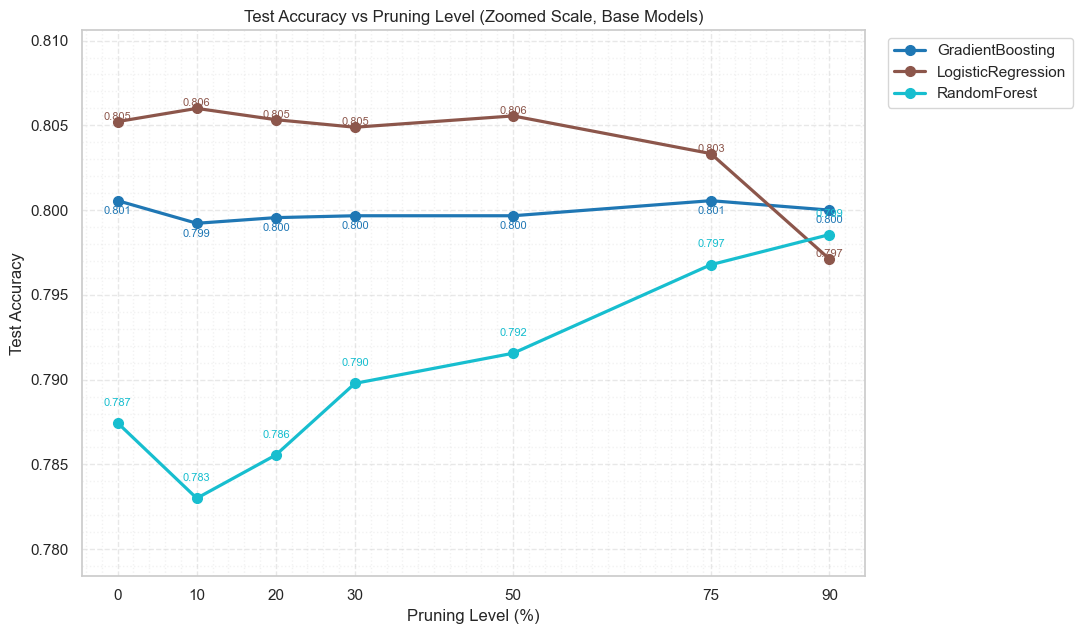

In [39]:
# ============================================================
# 9. VISUAL 1: TEST ACCURACY VS PRUNING LEVEL (LINE PLOT)
# ============================================================

plot_df = results_viz_df.copy()
plot_df["pruning_percent"] = plot_df["pruning_percent"].astype(float)

# Exclude ensemble models from this plot
exclude_models = {"SoftVotingEnsemble", "WeightedSoftVoting"}
plot_df = plot_df[~plot_df["model"].isin(exclude_models)].copy()

models = sorted(plot_df["model"].unique())
color_cycle = plt.cm.tab10(np.linspace(0, 1, max(3, len(models))))

fig, ax = plt.subplots(figsize=(11, 6.5))

all_y = plot_df["test_accuracy"].to_numpy(dtype=float)
y_min = float(np.min(all_y))
y_max = float(np.max(all_y))
spread = max(0.002, y_max - y_min)
pad = max(0.003, spread * 0.20)

for i, model_name in enumerate(models):
    m = plot_df[plot_df["model"] == model_name].sort_values("pruning_percent")
    x = m["pruning_percent"].to_numpy()
    y = m["test_accuracy"].to_numpy(dtype=float)

    ax.plot(
        x,
        y,
        marker="o",
        markersize=7,
        linewidth=2.3,
        color=color_cycle[i],
        label=model_name
    )

    for xx, yy in zip(x, y):
        
        offset = (i - (len(models) - 1) / 2) * 0.0009
        ax.text(xx, yy + offset, f"{yy:.3f}", fontsize=8, ha="center", va="bottom", color=color_cycle[i])

ax.set_title("Test Accuracy vs Pruning Level (Zoomed Scale, Base Models)")
ax.set_xlabel("Pruning Level (%)")
ax.set_ylabel("Test Accuracy")
ax.set_xticks([0, 10,20,30,50,75,90])
ax.set_ylim(max(0, y_min - pad), min(1, y_max + pad))

ax.yaxis.set_major_locator(plt.MaxNLocator(8))
ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.grid(True, which="minor", linestyle=":", alpha=0.25)
ax.minorticks_on()

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()



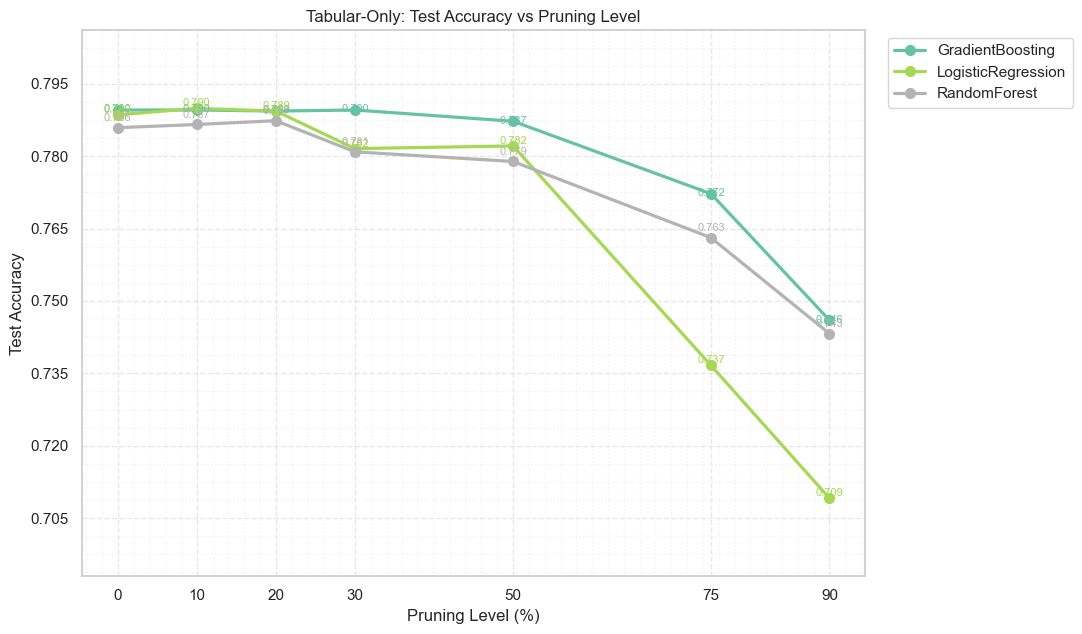

In [40]:
# ============================================================
# 9B. VISUAL 1B: TABULAR-ONLY TEST ACCURACY VS PRUNING LEVEL
# ============================================================

TABULAR_RESULTS_CSV = find_existing_file([
    "pruning_experiment_results_tabular_attributes.csv",
])

if TABULAR_RESULTS_CSV is None:
    print("Tabular-only pruning chart skipped: results CSV not found.")
else:
    tabular_viz_df = pd.read_csv(TABULAR_RESULTS_CSV)
    tabular_viz_df["pruning_percent"] = tabular_viz_df["pruning_percent"].astype(float)

    tabular_models = sorted(tabular_viz_df["model"].unique())
    tabular_colors = plt.cm.Set2(np.linspace(0, 1, max(3, len(tabular_models))))

    fig, ax = plt.subplots(figsize=(11, 6.5))

    all_y = tabular_viz_df["test_accuracy"].to_numpy(dtype=float)
    y_min = float(np.min(all_y))
    y_max = float(np.max(all_y))
    spread = max(0.002, y_max - y_min)
    pad = max(0.003, spread * 0.20)

    for i, model_name in enumerate(tabular_models):
        m = tabular_viz_df[tabular_viz_df["model"] == model_name].sort_values("pruning_percent")
        x = m["pruning_percent"].to_numpy()
        y = m["test_accuracy"].to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            marker="o",
            markersize=7,
            linewidth=2.3,
            color=tabular_colors[i],
            label=model_name,
        )

        for xx, yy in zip(x, y):
            offset = (i - (len(tabular_models) - 1) / 2) * 0.0009
            ax.text(xx, yy + offset, f"{yy:.3f}", fontsize=8, ha="center", va="bottom", color=tabular_colors[i])

    ax.set_title("Tabular-Only: Test Accuracy vs Pruning Level")
    ax.set_xlabel("Pruning Level (%)")
    ax.set_ylabel("Test Accuracy")
    ax.set_xticks([0,10,20,30,50,75,90])
    ax.set_ylim(max(0, y_min - pad), min(1, y_max + pad))

    ax.yaxis.set_major_locator(plt.MaxNLocator(8))
    ax.grid(True, which="major", linestyle="--", alpha=0.45)
    ax.grid(True, which="minor", linestyle=":", alpha=0.25)
    ax.minorticks_on()

    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()



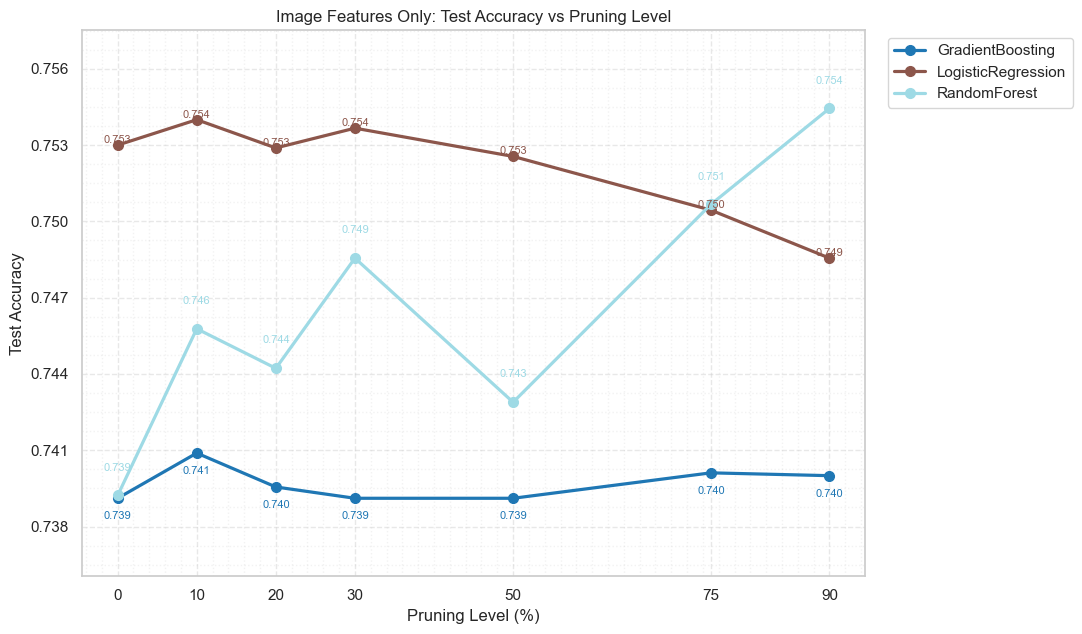

In [41]:
# ============================================================
# 9C. VISUAL 1C: IMAGE-ONLY TEST ACCURACY VS PRUNING LEVEL
# ============================================================

IMAGE_RESULTS_CSV = find_existing_file([
    "pruning_experiment_results_image_features.csv",
])

if IMAGE_RESULTS_CSV is None:
    print("Image-only pruning chart skipped: results CSV not found.")
else:
    image_viz_df = pd.read_csv(IMAGE_RESULTS_CSV)
    image_viz_df["pruning_percent"] = image_viz_df["pruning_percent"].astype(float)

    image_models = sorted(image_viz_df["model"].unique())
    image_colors = plt.cm.tab20(np.linspace(0, 1, max(3, len(image_models))))

    fig, ax = plt.subplots(figsize=(11, 6.5))

    all_y = image_viz_df["test_accuracy"].to_numpy(dtype=float)
    y_min = float(np.min(all_y))
    y_max = float(np.max(all_y))
    spread = max(0.002, y_max - y_min)
    pad = max(0.003, spread * 0.20)

    for i, model_name in enumerate(image_models):
        m = image_viz_df[image_viz_df["model"] == model_name].sort_values("pruning_percent")
        x = m["pruning_percent"].to_numpy()
        y = m["test_accuracy"].to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            marker="o",
            markersize=7,
            linewidth=2.3,
            color=image_colors[i],
            label=model_name
        )

        for xx, yy in zip(x, y):

            offset = (i - (len(image_models) - 1) / 2) * 0.0009
            ax.text(xx, yy + offset, f"{yy:.3f}", fontsize=8, ha="center", va="bottom", color=image_colors[i])

    ax.set_title("Image Features Only: Test Accuracy vs Pruning Level")
    ax.set_xlabel("Pruning Level (%)")
    ax.set_ylabel("Test Accuracy")
    ax.set_xticks([0, 10, 20, 30, 50, 75, 90])
    ax.set_ylim(max(0, y_min - pad), min(1, y_max + pad))

    ax.yaxis.set_major_locator(plt.MaxNLocator(8))
    ax.grid(True, which="major", linestyle="--", alpha=0.45)
    ax.grid(True, which="minor", linestyle=":", alpha=0.25)
    ax.minorticks_on()

    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()

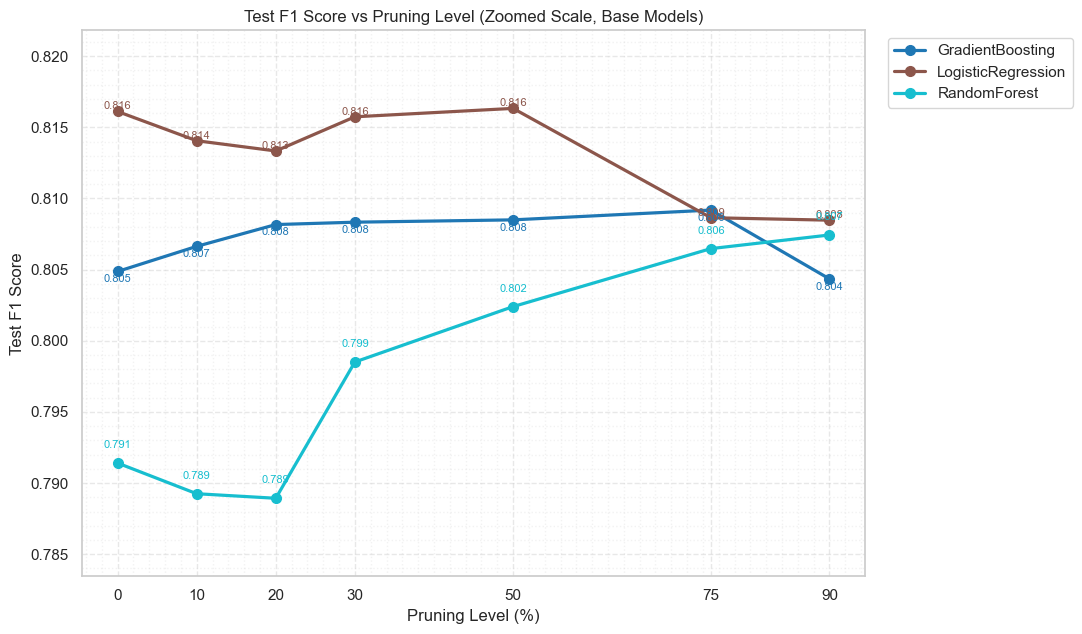

In [42]:
# ============================================================
# 9D. VISUAL 1D: TEST F1 VS PRUNING LEVEL (LINE PLOT)
# ============================================================

plot_f1_df = results_viz_df.copy()
plot_f1_df["pruning_percent"] = plot_f1_df["pruning_percent"].astype(float)

# Exclude ensemble models from this plot
exclude_models = {"SoftVotingEnsemble", "WeightedSoftVoting"}
plot_f1_df = plot_f1_df[~plot_f1_df["model"].isin(exclude_models)].copy()

f1_models = sorted(plot_f1_df["model"].unique())
f1_color_cycle = plt.cm.tab10(np.linspace(0, 1, max(3, len(f1_models))))

fig, ax = plt.subplots(figsize=(11, 6.5))

all_y = plot_f1_df["test_f1"].to_numpy(dtype=float)
y_min = float(np.min(all_y))
y_max = float(np.max(all_y))
spread = max(0.002, y_max - y_min)
pad = max(0.003, spread * 0.20)

for i, model_name in enumerate(f1_models):
    m = plot_f1_df[plot_f1_df["model"] == model_name].sort_values("pruning_percent")
    x = m["pruning_percent"].to_numpy()
    y = m["test_f1"].to_numpy(dtype=float)

    ax.plot(
        x,
        y,
        marker="o",
        markersize=7,
        linewidth=2.3,
        color=f1_color_cycle[i],
        label=model_name
    )

    for xx, yy in zip(x, y):
        offset = (i - (len(f1_models) - 1) / 2) * 0.0009
        ax.text(xx, yy + offset, f"{yy:.3f}", fontsize=8, ha="center", va="bottom", color=f1_color_cycle[i])

ax.set_title("Test F1 Score vs Pruning Level (Zoomed Scale, Base Models)")
ax.set_xlabel("Pruning Level (%)")
ax.set_ylabel("Test F1 Score")
ax.set_xticks([0, 10,20,30,50,75,90])
ax.set_ylim(max(0, y_min - pad), min(1, y_max + pad))

ax.yaxis.set_major_locator(plt.MaxNLocator(8))
ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.grid(True, which="minor", linestyle=":", alpha=0.25)
ax.minorticks_on()

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()


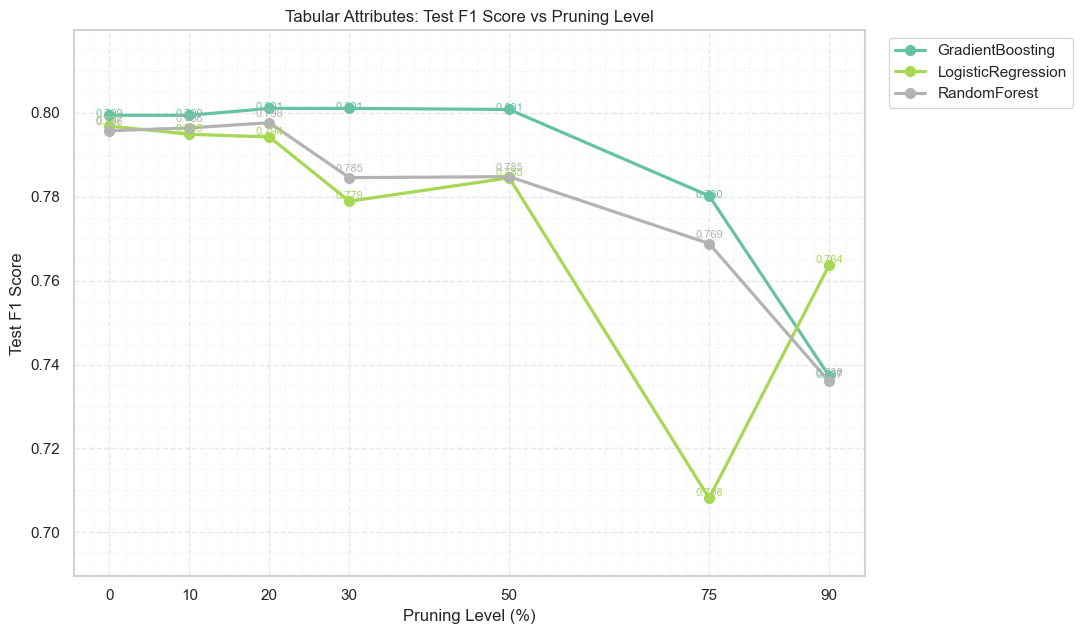

In [43]:
# ============================================================
# 9E. VISUAL 1E: TABULAR-ONLY TEST F1 VS PRUNING LEVEL
# ============================================================

if TABULAR_RESULTS_CSV is None:
    print("Tabular-only F1 chart skipped: results CSV not found.")
else:
    tabular_f1_viz_df = pd.read_csv(TABULAR_RESULTS_CSV)
    tabular_f1_viz_df["pruning_percent"] = tabular_f1_viz_df["pruning_percent"].astype(float)

    tabular_f1_models = sorted(tabular_f1_viz_df["model"].unique())
    tabular_f1_colors = plt.cm.Set2(np.linspace(0, 1, max(3, len(tabular_f1_models))))

    fig, ax = plt.subplots(figsize=(11, 6.5))

    all_y = tabular_f1_viz_df["test_f1"].to_numpy(dtype=float)
    y_min = float(np.min(all_y))
    y_max = float(np.max(all_y))
    spread = max(0.002, y_max - y_min)
    pad = max(0.003, spread * 0.20)

    for i, model_name in enumerate(tabular_f1_models):
        m = tabular_f1_viz_df[tabular_f1_viz_df["model"] == model_name].sort_values("pruning_percent")
        x = m["pruning_percent"].to_numpy()
        y = m["test_f1"].to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            marker="o",
            markersize=7,
            linewidth=2.3,
            color=tabular_f1_colors[i],
            label=model_name,
        )

        for xx, yy in zip(x, y):
            offset = (i - (len(tabular_f1_models) - 1) / 2) * 0.0009
            ax.text(xx, yy + offset, f"{yy:.3f}", fontsize=8, ha="center", va="bottom", color=tabular_f1_colors[i])

    ax.set_title("Tabular Attributes: Test F1 Score vs Pruning Level")
    ax.set_xlabel("Pruning Level (%)")
    ax.set_ylabel("Test F1 Score")
    ax.set_xticks([0, 10,20,30,50,75,90])
    ax.set_ylim(max(0, y_min - pad), min(1, y_max + pad))

    ax.yaxis.set_major_locator(plt.MaxNLocator(8))
    ax.grid(True, which="major", linestyle="--", alpha=0.45)
    ax.grid(True, which="minor", linestyle=":", alpha=0.25)
    ax.minorticks_on()

    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()


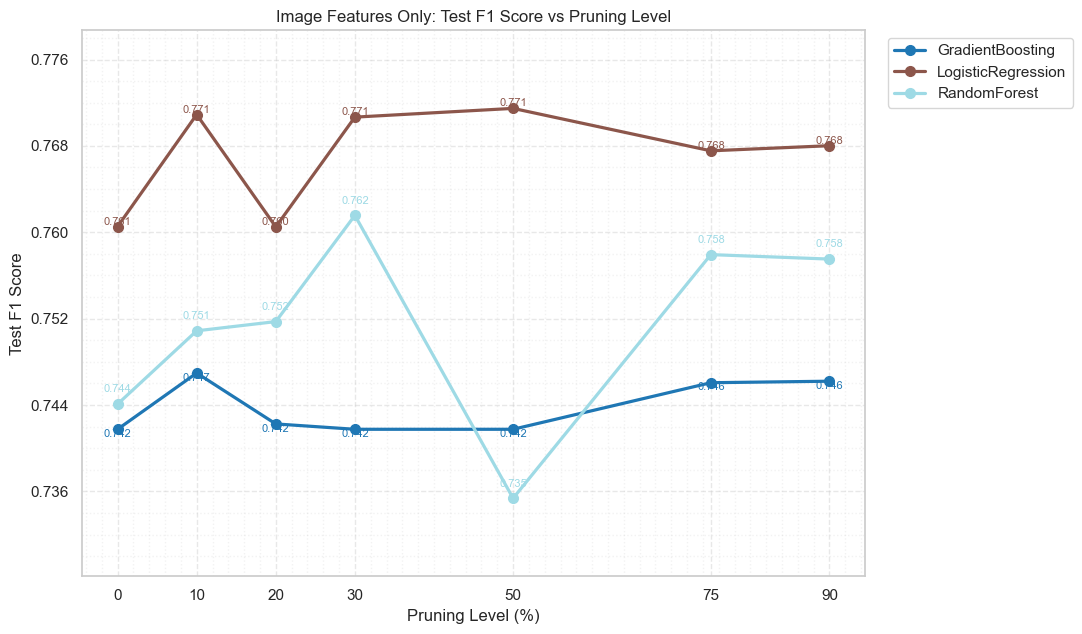

In [44]:
# ============================================================
# 9F. VISUAL 1F: IMAGE-ONLY TEST F1 VS PRUNING LEVEL
# ============================================================

if IMAGE_RESULTS_CSV is None:
    print("Image-only F1 chart skipped: results CSV not found.")
else:
    image_f1_viz_df = pd.read_csv(IMAGE_RESULTS_CSV)
    image_f1_viz_df["pruning_percent"] = image_f1_viz_df["pruning_percent"].astype(float)

    image_f1_models = sorted(image_f1_viz_df["model"].unique())
    image_f1_colors = plt.cm.tab20(np.linspace(0, 1, max(3, len(image_f1_models))))

    fig, ax = plt.subplots(figsize=(11, 6.5))

    all_y = image_f1_viz_df["test_f1"].to_numpy(dtype=float)
    y_min = float(np.min(all_y))
    y_max = float(np.max(all_y))
    spread = max(0.002, y_max - y_min)
    pad = max(0.003, spread * 0.20)

    for i, model_name in enumerate(image_f1_models):
        m = image_f1_viz_df[image_f1_viz_df["model"] == model_name].sort_values("pruning_percent")
        x = m["pruning_percent"].to_numpy()
        y = m["test_f1"].to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            marker="o",
            markersize=7,
            linewidth=2.3,
            color=image_f1_colors[i],
            label=model_name
        )

        for xx, yy in zip(x, y):
            offset = (i - (len(image_f1_models) - 1) / 2) * 0.0009
            ax.text(xx, yy + offset, f"{yy:.3f}", fontsize=8, ha="center", va="bottom", color=image_f1_colors[i])

    ax.set_title("Image Features Only: Test F1 Score vs Pruning Level")
    ax.set_xlabel("Pruning Level (%)")
    ax.set_ylabel("Test F1 Score")
    ax.set_xticks([0, 10,20,30,50,75,90])
    ax.set_ylim(max(0, y_min - pad), min(1, y_max + pad))

    ax.yaxis.set_major_locator(plt.MaxNLocator(8))
    ax.grid(True, which="major", linestyle="--", alpha=0.45)
    ax.grid(True, which="minor", linestyle=":", alpha=0.25)
    ax.minorticks_on()

    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()


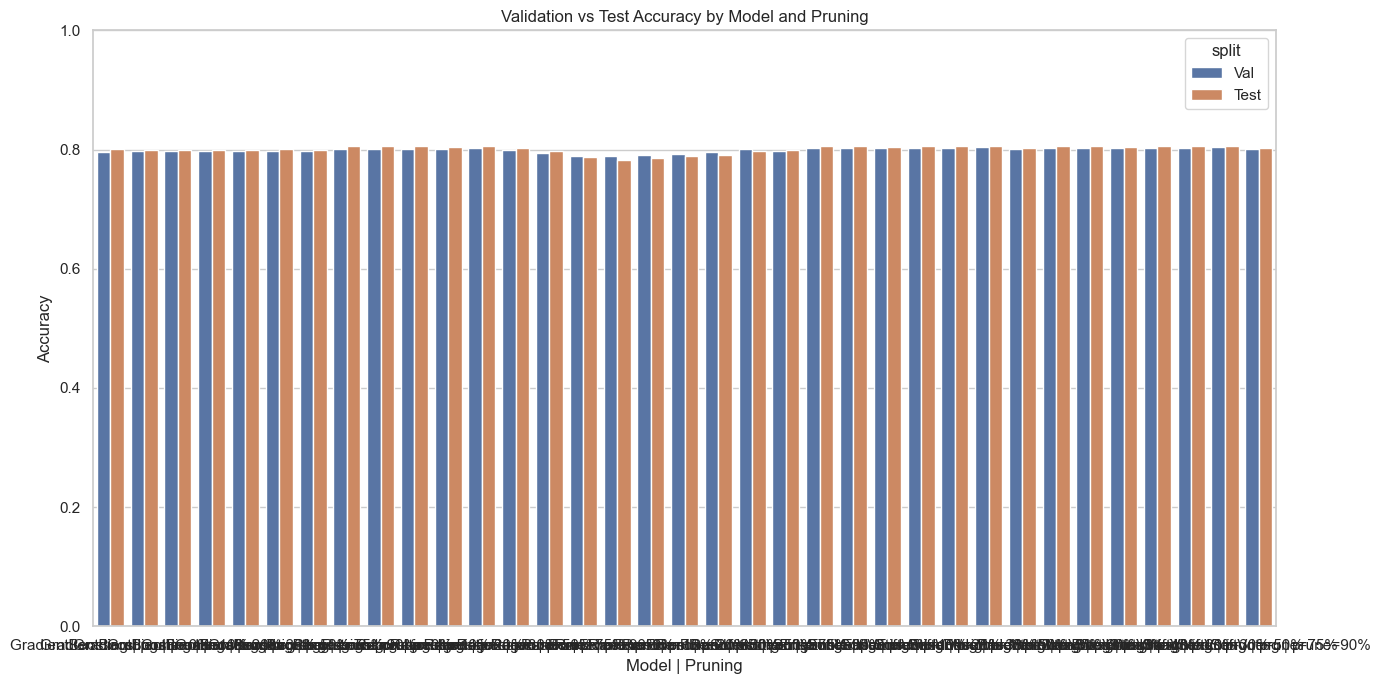

In [45]:
# ============================================================
# 10. VISUAL 2: VALIDATION VS TEST ACCURACY (GROUPED BAR)
# ============================================================

bar_df = results_viz_df[["model", "pruning_percent", "val_accuracy", "test_accuracy"]].copy()
bar_df["setting"] = bar_df["model"] + " | prune=" + bar_df["pruning_percent"].astype(str) + "%"

melt_df = bar_df.melt(
    id_vars=["model", "pruning_percent", "setting"],
    value_vars=["val_accuracy", "test_accuracy"],
    var_name="split",
    value_name="accuracy",
)
melt_df["split"] = melt_df["split"].str.replace("_accuracy", "", regex=False).str.title()

plt.figure(figsize=(14, 7))
if HAS_SEABORN:
    sns.barplot(data=melt_df, x="setting", y="accuracy", hue="split")
else:
    pivot = melt_df.pivot(index="setting", columns="split", values="accuracy")
    x = np.arange(len(pivot.index))
    n_cols = len(pivot.columns)
    width = 0.8 / max(1, n_cols)

    for i, col in enumerate(pivot.columns):
        offset = (i - (n_cols - 1) / 2) * width
        plt.bar(x + offset, pivot[col].values, width=width, label=str(col))

    plt.xticks(x, pivot.index, rotation=45, ha="right")
    plt.legend()

plt.title("Validation vs Test Accuracy by Model and Pruning")
plt.xlabel("Model | Pruning")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


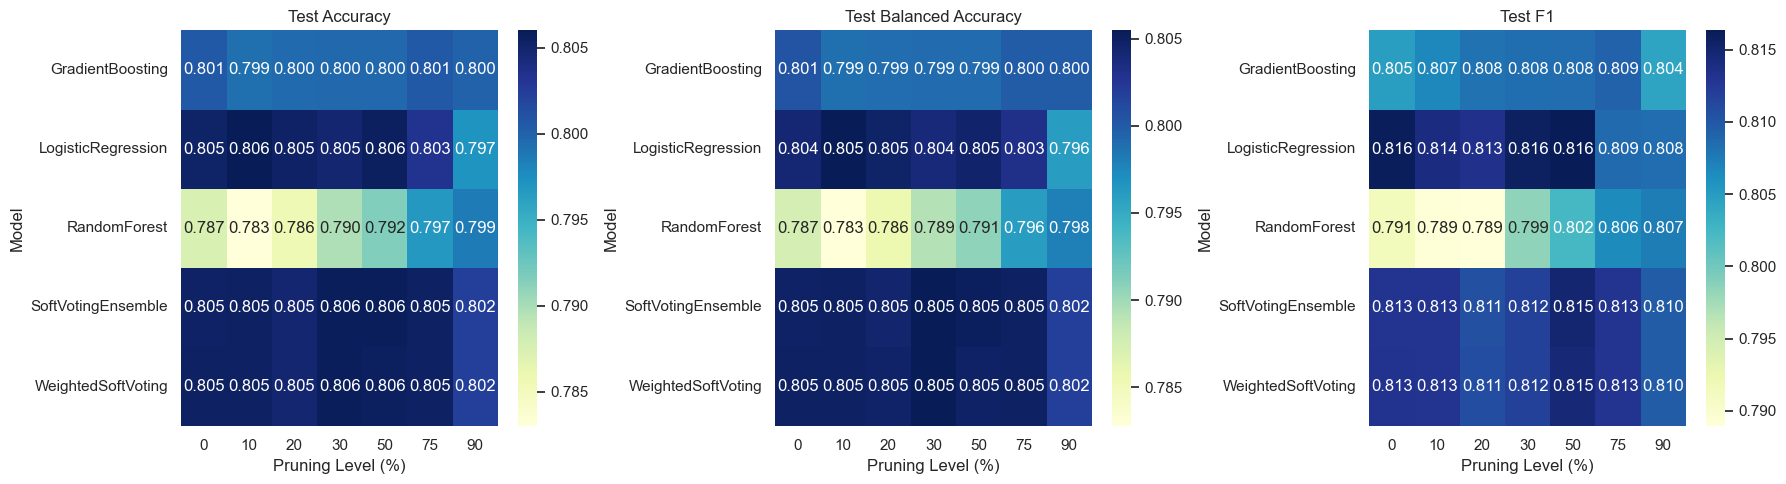

In [46]:
# ============================================================
# 11. VISUAL 3: HEATMAPS (ACCURACY / BALANCED ACC / F1)
# ============================================================

metrics = [
    ("test_accuracy", "Test Accuracy"),
    ("test_balanced_accuracy", "Test Balanced Accuracy"),
    ("test_f1", "Test F1"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric_col, title) in zip(axes, metrics):
    heat = results_viz_df.pivot(index="model", columns="pruning_percent", values=metric_col)
    heat = heat.reindex(sorted(heat.index), axis=0)
    heat = heat.reindex(sorted(heat.columns), axis=1)
    heat.index.name = "Model"
    heat.columns.name = "Pruning Level (%)"

    draw_heatmap(ax, heat, title, cmap="YlGnBu", value_fmt=".3f", show_cbar=True)

plt.tight_layout()
plt.show()


In [47]:
# ============================================================
# 12. VISUAL 4: CONFUSION MATRIX (BEST SETTING)
# ============================================================

SELECTED_FEATURES_JSON = find_existing_file([
    "selected_features_from_images_plus_attributes.json",
    "selected_features_from_images.json",
    "selected_features.json",
])

BEST_PARAMS_JSON = find_existing_file([
    "best_hyperparameters_by_pruning_from_images_plus_attributes.json",
    "best_hyperparameters_by_pruning_from_images.json",
    "best_hyperparameters_by_pruning.json",
    "best_hyperparameters.json",
])

BEST_THRESHOLDS_JSON = find_existing_file([
    "best_thresholds_by_pruning_from_images_plus_attributes.json",
    "best_thresholds_by_pruning_from_images.json",
    "best_thresholds_by_pruning.json",
])

cache_candidates = sorted(glob.glob(os.path.join(DATASET_ROOT, "celeba_image_tabular_features_notf_*.npz")))
if not cache_candidates:
    cache_candidates = sorted(glob.glob(os.path.join(DATASET_ROOT, "celeba_image_features_notf_*.npz")))

if not cache_candidates:
    print("Confusion matrix skipped: feature cache .npz not found.")
else:
    CACHE_FILE = cache_candidates[-1]
    print("Using cache:", CACHE_FILE)

    if SELECTED_FEATURES_JSON is None or BEST_PARAMS_JSON is None:
        print("Confusion matrix skipped: missing selected_features or best_hyperparameters file.")
    else:
        with open(SELECTED_FEATURES_JSON, "r") as f:
            selected_feature_map_viz = json.load(f)

        with open(BEST_PARAMS_JSON, "r") as f:
            best_params_map_viz = json.load(f)

        threshold_map_viz = {}
        if BEST_THRESHOLDS_JSON is not None:
            with open(BEST_THRESHOLDS_JSON, "r") as f:
                threshold_map_viz = json.load(f)

        z = np.load(CACHE_FILE, allow_pickle=True)

        if {"X_train_img", "X_train_attr", "X_test_img", "X_test_attr", "y_train", "y_test"}.issubset(set(z.files)):
            X_train_viz = np.hstack([z["X_train_img"], z["X_train_attr"]]).astype(np.float32)
            X_test_viz = np.hstack([z["X_test_img"], z["X_test_attr"]]).astype(np.float32)
            y_train_viz = z["y_train"].astype(np.int8)
            y_test_viz = z["y_test"].astype(np.int8)

            image_feat_n = z["X_train_img"].shape[1]
            if "attr_feature_cols" in z.files:
                attr_cols = [str(x) for x in z["attr_feature_cols"].tolist()]
            else:
                attr_cols = [f"attr_{i}" for i in range(z["X_train_attr"].shape[1])]
            feature_names_viz = [f"img_feat_{i}" for i in range(image_feat_n)] + attr_cols
        else:
            X_train_viz = z["X_train"].astype(np.float32)
            X_test_viz = z["X_test"].astype(np.float32)
            y_train_viz = z["y_train"].astype(np.int8)
            y_test_viz = z["y_test"].astype(np.int8)
            feature_names_viz = [f"feat_{i}" for i in range(X_train_viz.shape[1])]

        feature_index_viz = {name: idx for idx, name in enumerate(feature_names_viz)}

        best_row = results_viz_df.sort_values("val_accuracy", ascending=False).iloc[0]
        best_model_name = str(best_row["model"])
        best_prune = str(int(best_row["pruning_percent"]))
        best_threshold = float(best_row["threshold"]) if "threshold" in results_viz_df.columns else 0.5

        model_classes_viz = {
            "LogisticRegression": LogisticRegression,
            "GradientBoosting": GradientBoostingClassifier,
            "RandomForest": RandomForestClassifier,
        }

        def get_params(model_name, prune_key):
            node = best_params_map_viz.get(model_name, {})
            if isinstance(node, dict) and prune_key in node:
                return node[prune_key]
            if isinstance(node, dict):
                return node
            return {}

        def get_threshold(model_name, prune_key, default_threshold):
            if not threshold_map_viz:
                return default_threshold
            node = threshold_map_viz.get(model_name, {})
            if isinstance(node, dict) and prune_key in node:
                return float(node[prune_key])
            return default_threshold

        def fit_base_model_and_probs(model_name, prune_key):
            selected = selected_feature_map_viz[model_name][prune_key]
            cols = [feature_index_viz[c] for c in selected if c in feature_index_viz]
            Xtr = X_train_viz[:, cols]
            Xte = X_test_viz[:, cols]
            clf = model_classes_viz[model_name](**get_params(model_name, prune_key))
            clf.fit(Xtr, y_train_viz)
            return clf.predict_proba(Xte)[:, 1]

        if best_model_name in model_classes_viz:
            probs_best = fit_base_model_and_probs(best_model_name, best_prune)
            t_best = get_threshold(best_model_name, best_prune, best_threshold)
            y_pred_best = (probs_best >= t_best).astype("int8")
            plot_title = f"Confusion Matrix: {best_model_name} (prune={best_prune}%)"
        else:
            base_names = ["LogisticRegression", "GradientBoosting", "RandomForest"]
            base_probs = []
            base_val_weights = []

            for bm in base_names:
                if bm in selected_feature_map_viz:
                    base_probs.append(fit_base_model_and_probs(bm, best_prune))
                    row = results_viz_df[(results_viz_df["model"] == bm) & (results_viz_df["pruning_percent"].astype(str) == best_prune)]
                    base_val_weights.append(float(row.iloc[0]["val_accuracy"]) if len(row) else 1.0)

            prob_stack = np.column_stack(base_probs)
            if best_model_name == "WeightedSoftVoting":
                w = np.array(base_val_weights, dtype=float)
                w = w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)
                probs_best = np.average(prob_stack, axis=1, weights=w)
            else:
                probs_best = prob_stack.mean(axis=1)

            y_pred_best = (probs_best >= best_threshold).astype("int8")
            plot_title = f"Confusion Matrix: {best_model_name} (prune={best_prune}%)"

        cm = confusion_matrix(y_test_viz, y_pred_best)
        cm_df = pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"])

        fig, ax = plt.subplots(figsize=(6, 5))
        draw_heatmap(ax, cm_df, plot_title, cmap="Blues", value_fmt="d", show_cbar=False)
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")
        plt.tight_layout()
        plt.show()


Using cache: /Users/sachivyas/Downloads/archive/celeba_image_tabular_features_notf_60000.npz


KeyboardInterrupt: 

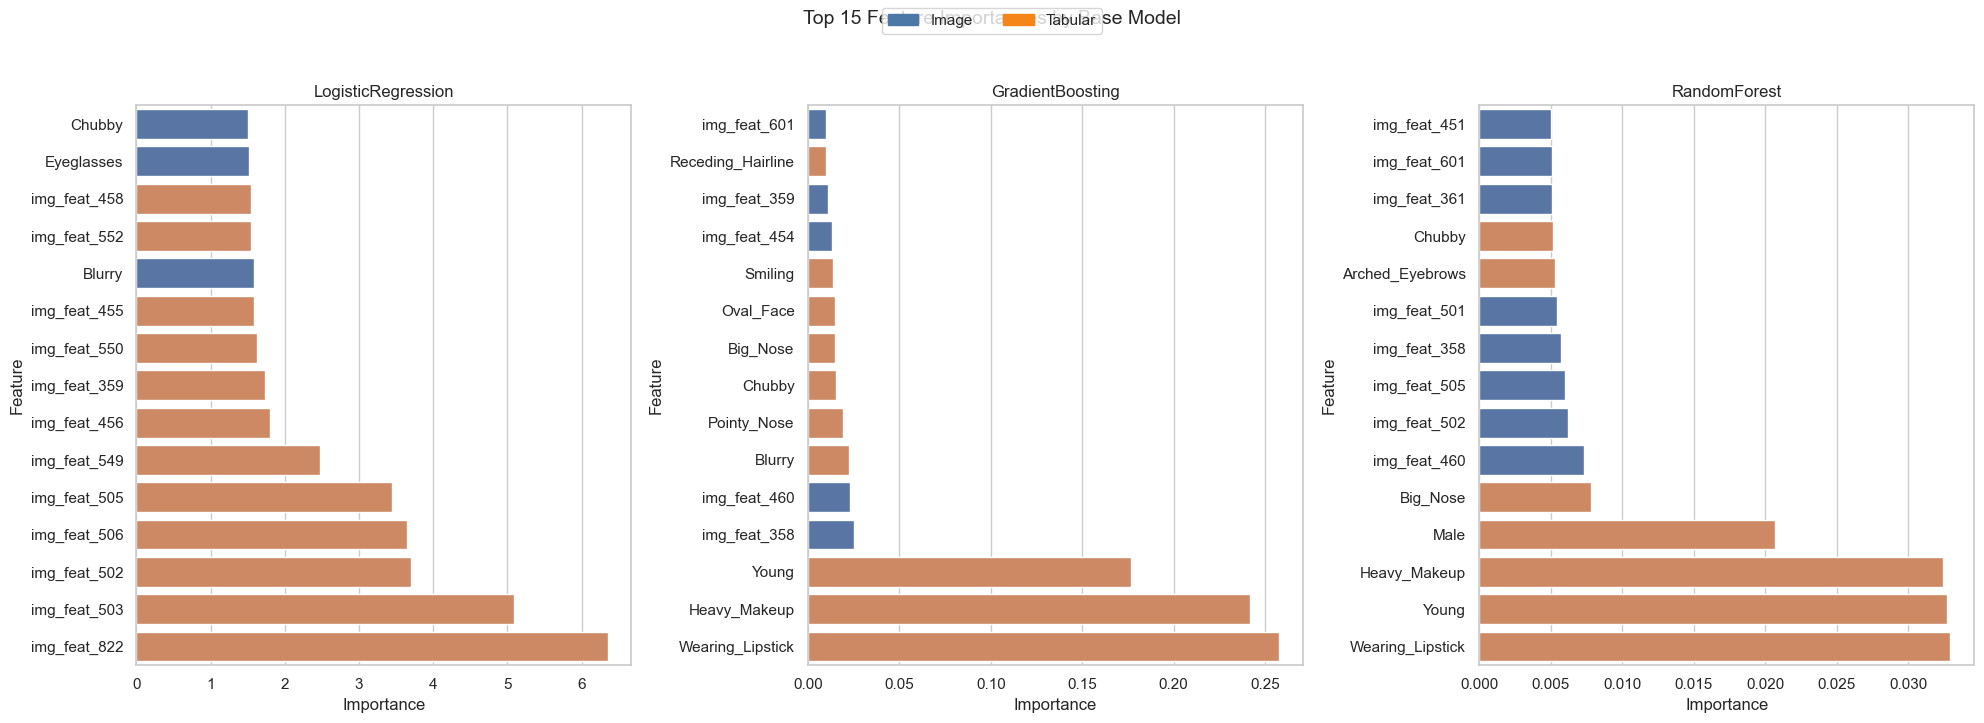

In [28]:
# ============================================================
# 13. VISUAL 5: TOP FEATURE IMPORTANCE (ALL BASE MODELS)
# ============================================================

base_models = ["LogisticRegression", "GradientBoosting", "RandomForest"]

# Keep plotting style deterministic by model order
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=False)

for ax, model_name in zip(axes, base_models):
    importance_csv_candidates = [
        f"{model_name.lower().replace(' ', '')}_feature_importance_from_images_plus_attributes.csv",
        f"{model_name.lower().replace(' ', '_')}_feature_importance_from_images_plus_attributes.csv",
        f"{model_name.lower().replace(' ', '')}_feature_importance_from_images.csv",
        f"{model_name.lower().replace(' ', '_')}_feature_importance_from_images.csv",
        f"{model_name.lower().replace(' ', '')}_feature_importance.csv",
        f"{model_name.lower().replace(' ', '_')}_feature_importance.csv",
    ]

    imp_csv = find_existing_file(importance_csv_candidates)

    if imp_csv is None:
        ax.axis("off")
        ax.text(0.5, 0.5, f"{model_name}\nimportance file not found", ha="center", va="center")
        continue

    imp_df = pd.read_csv(imp_csv).head(15).copy()

    def feature_source(name):
        name = str(name)
        if name.startswith("img_feat_") or name.startswith("feat_"):
            return "Image"
        return "Tabular"

    imp_df["source"] = imp_df["feature"].apply(feature_source)

    # Plot top feature at top
    ordered = imp_df.iloc[::-1]

    if HAS_SEABORN:
        sns.barplot(
            data=ordered,
            y="feature",
            x="importance",
            hue="source",
            dodge=False,
            ax=ax
        )
        # Avoid repeated legends across subplots
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    else:
        colors = ["#4c78a8" if s == "Image" else "#f58518" for s in ordered["source"]]
        ax.barh(ordered["feature"], ordered["importance"], color=colors)

    ax.set_title(model_name)
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

# Single shared legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#4c78a8", label="Image"),
    Patch(color="#f58518", label="Tabular"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=True)
fig.suptitle("Top 15 Feature Importances by Base Model", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Feature dictionary for image-derived features
feature_schema = pd.DataFrame([
    {"group": "Thumbnail pixels", "start_idx": 0,   "end_idx": 767, "count": 768, "meaning": "Low-res 16x16x3 RGB pixel values"},
    {"group": "Channel means",    "start_idx": 768, "end_idx": 770, "count": 3,   "meaning": "Average R/G/B intensity"},
    {"group": "Channel stds",     "start_idx": 771, "end_idx": 773, "count": 3,   "meaning": "R/G/B intensity variation"},
    {"group": "RGB histograms",   "start_idx": 774, "end_idx": 821, "count": 48,  "meaning": "16-bin histogram per channel (R,G,B)"},
    {"group": "Gradient stats",   "start_idx": 822, "end_idx": 824, "count": 3,   "meaning": "Texture/edge strength stats: mean, std, 75th percentile"},
])
feat_idx = 822
row = feature_schema[(feature_schema.start_idx <= feat_idx) & (feature_schema.end_idx >= feat_idx)].iloc[0]
print(f"img_feat_{feat_idx} -> {row['group']} ({row['meaning']})")


print(feature_schema)
feature_schema.to_csv(os.path.join(DATASET_ROOT, "project_results2", "img_feature_schema.csv"), index=False)


img_feat_822 -> Gradient stats (Texture/edge strength stats: mean, std, 75th percentile)
              group  start_idx  end_idx  count  \
0  Thumbnail pixels          0      767    768   
1     Channel means        768      770      3   
2      Channel stds        771      773      3   
3    RGB histograms        774      821     48   
4    Gradient stats        822      824      3   

                                             meaning  
0                   Low-res 16x16x3 RGB pixel values  
1                            Average R/G/B intensity  
2                          R/G/B intensity variation  
3               16-bin histogram per channel (R,G,B)  
4  Texture/edge strength stats: mean, std, 75th p...  
